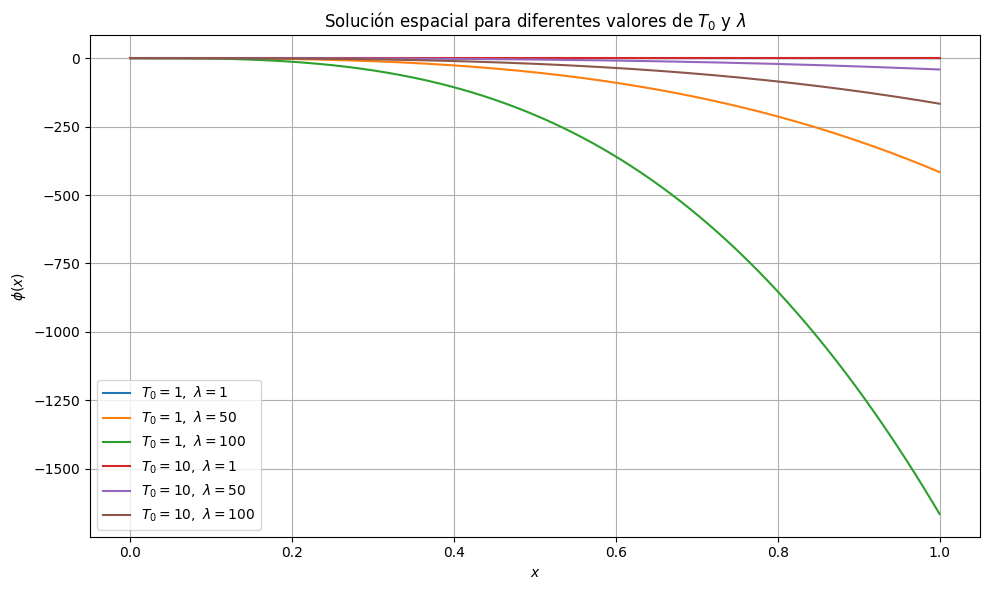

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# VALORES DE lambda Y T0
# ==========================================

lambda_values = np.array([1, 50,100])
T0_values = np.array([1 ,10])

# Dominio de x
x = np.linspace(0, 1, 500)

# Número de términos de la serie
N = 5


# ==========================================
# FUNCIÓN DE LA SOLUCIÓN POR SERIES
# ==========================================

def phi_series(x, lam, T0, N):

    # k = (lambda^2 + 1) / T0
    k = (lam**2 + 1) / T0

    # Coeficientes a0, a1, ..., aN
    a = np.zeros(N + 1)

    # Normalización para graficar
    a[0] = 1
    a[1] = 0

    # Recurrencia:
    # a_(n+3) = -k*a_n / [(n+3)(n+2)]

    for n in range(N - 2):
        a[n + 3] = -k * a[n] / ((n + 3) * (n + 2))

    # Evaluamos la serie
    phi = np.zeros_like(x)

    for n in range(N + 1):
        phi += a[n] * x**n

    return phi


# ==========================================
# UNA SOLA GRÁFICA
# ==========================================

plt.figure(figsize=(10, 6))

for T0 in T0_values:

    for lam in lambda_values:

        phi = phi_series(x, lam, T0, N)

        plt.plot(
            x,
            phi,
            label=f"$T_0={T0},\\ \\lambda={lam}$"
        )


# ==========================================
# CONFIGURACIÓN DE LA GRÁFICA
# ==========================================

plt.xlabel("$x$")
plt.ylabel("$\\phi(x)$")
plt.title(
    "Solución espacial para diferentes valores de $T_0$ y $\\lambda$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()